# Naive Bayes Classifiers

Naive Bayes is a machine learning classification algorithm that predicts the category of a data point using probability. It assumes that all features are independent of each other. Naive Bayes performs well in many real-world applications such as spam filtering, document categorization and sentiment analysis.

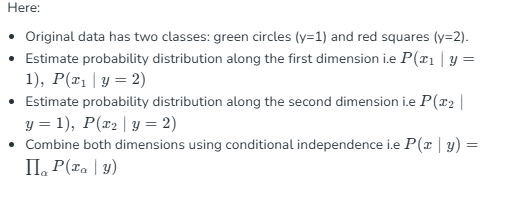

# Key Features of Naive Bayes Classifiers

- **Based on Bayes' Theorem:** Naive Bayes uses Bayes' Theorem to classify data based on the probabilities of different classes given the features of the data.
- **High-Dimensional Data:** Commonly used in **high-dimensional text classification** tasks.
- **Simple and Fast:** 
  - A **probabilistic classifier** with very few parameters.
  - Can **predict quickly** compared to other classification algorithms.
- **Feature Independence Assumption:** 
  - Assumes that each feature is **independent** of the others.
  - Each feature contributes to predictions **without considering relationships** with other features.
- **Applications:** 
  - **Spam filtration**
  - **Sentiment analysis**
  - **Article classification**
  - Many other text classification tasks.


# Why It Is Called Naive Bayes?

- Named **"Naive"** because it assumes that **the presence of one feature does not affect other features**.  
- The **"Bayes"** part comes from its basis in **Bayes’ Theorem**.

---

## Example: Weather Dataset for Playing Golf

| Outlook   | Temperature | Humidity | Windy | Play Golf |
|-----------|-------------|----------|-------|-----------|
| Rainy     | Hot         | High     | False | Yes       |
| Rainy     | Hot         | High     | True  | No        |
| Overcast  | Hot         | High     | False | Yes       |
| Sunny     | Mild        | High     | False | Yes       |
| Sunny     | Cool        | Normal   | False | Yes       |
| Sunny     | Cool        | Normal   | True  | No        |
| Overcast  | Cool        | Normal   | True  | Yes       |
| Rainy     | Mild        | High     | False | No        |
| Rainy     | Cool        | Normal   | False | Yes       |
| Sunny     | Mild        | Normal   | False | Yes       |
| Rainy     | Mild        | Normal   | True  | Yes       |
| Overcast  | Mild        | High     | True  | Yes       |
| Overcast  | Hot         | Normal   | False | Yes       |
| Sunny     | Mild        | High     | True  | No        |

---

## Dataset Structure

- **Feature Matrix (X):** Contains all **vectors (rows)** of the dataset, each consisting of the **dependent features**.  
  - Features in this dataset: `Outlook`, `Temperature`, `Humidity`, `Windy`

- **Response Vector (Y):** Contains the **class variable (output)** for each row of the feature matrix.  
  - Class variable in this dataset: `Play Golf`


# Assumptions of Naive Bayes

- **Feature Independence:** Each feature is assumed to be **independent** of all other features when classifying data.  
- **Continuous Features are Normally Distributed:** Continuous features are assumed to follow a **normal distribution** within each class.  
- **Discrete Features have Multinomial Distributions:** Discrete features are assumed to follow a **multinomial distribution** within each class.  
- **Features are Equally Important:** All features are assumed to contribute **equally** to predicting the class label.  
- **No Missing Data:** The dataset should **not contain any missing values**.


# Introduction to Bayes' Theorem and Naive Bayes Classifier

## Bayes' Theorem
- Provides a way to **reverse conditional probabilities**.
- Formula:

\[
P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}
\]

Where:  
- \(P(y|X)\) → **Posterior probability** (probability of class \(y\) given features \(X\))  
- \(P(X|y)\) → **Likelihood** (probability of features \(X\) given class \(y\))  
- \(P(y)\) → **Prior probability** of class \(y\)  
- \(P(X)\) → **Marginal likelihood or evidence**

---

## Naive Bayes Working

### 1. Terminology
- Class label: \(y\) (e.g., "Yes" or "No" for playing golf)  
- Feature vector: \(X = (x_1, x_2, ..., x_n)\) (e.g., Outlook, Temperature, Humidity, Wind)  
- Example row: \(X = (Rainy, Hot, High, False), y = No\)  
  - Goal: Probability that someone will **not play golf** given the weather conditions.

### 2. The Naive Assumption
- Assumes **all features are independent** given the class:

\[
P(x_1, x_2, ..., x_n | y) = \prod_{i=1}^n P(x_i | y)
\]

- Bayes’ theorem becomes:

\[
P(y|x_1, ..., x_n) \propto P(y) \cdot \prod_{i=1}^n P(x_i|y)
\]

### 3. Constructing the Classifier
- Compute posterior for each class and select the class with **highest probability**:

\[
\hat{y} = \arg\max_y P(y) \cdot \prod_{i=1}^n P(x_i|y)
\]

---

## Example: Weather Dataset for Golf
- Features: Outlook (Sunny, Rainy, Overcast), Temperature (Hot, Mild, Cool), Humidity (High, Normal), Wind (True, False)  
- Input: \(X = (Sunny, Hot, Normal, False)\)  
- Goal: Predict **Play Golf (Yes/No)**

### 4. Pre-computed Probabilities
- Class probabilities:

\[
P(Yes) = \frac{9}{14}, \quad P(No) = \frac{5}{14}
\]

- Conditional probabilities:    

| Feature      | Value  | P(Value|Yes) | P(Value|No) |    
|--------------|--------|--------------|-------------|      
| Outlook      | Sunny  | 2/9          | 3/5         |    
| Temperature  | Hot    | 2/9          | 2/5         |      
| Humidity     | Normal | 6/9          | 1/5         |      
| Wind         | False  | 6/9          | 2/5         |      


### 5. Posterior Probabilities
- For Class = Yes:

\[
P(Yes | today) \propto \frac{2}{9} \cdot \frac{2}{9} \cdot \frac{6}{9} \cdot \frac{6}{9} \cdot \frac{9}{14} \approx 0.02116
\]

- For Class = No:

\[
P(No | today) \propto \frac{3}{5} \cdot \frac{2}{5} \cdot \frac{1}{5} \cdot \frac{2}{5} \cdot \frac{5}{14} \approx 0.0068
\]

- Normalized probabilities:

\[
P(Yes | today) = \frac{0.02116}{0.02116+0.0068} \approx 0.756
\]

\[
P(No | today) = \frac{0.0068}{0.02116+0.0068} \approx 0.244
\]

- **Final Prediction:** Yes (Play Golf)

---

## Naive Bayes for Continuous Features
- Assumes **Gaussian distribution** for continuous features:

\[
P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)
\]

Where:  
- \(\mu_y\) = mean of feature \(x_i\) for class \(y\)  
- \(\sigma_y^2\) = variance of feature \(x_i\) for class \(y\)  

- This method is called **Gaussian Naive Bayes**.


# Types, Advantages, Disadvantages, and Applications of Naive Bayes

## Types of Naive Bayes Models

1. **Gaussian Naive Bayes**
   - Used for **continuous features**.
   - Assumes feature values are **normally distributed (Gaussian distribution)**.
   - Bell-shaped curve symmetric about the mean.

2. **Multinomial Naive Bayes**
   - Used when features represent **frequencies** (e.g., word counts in documents).
   - Commonly applied in **text classification** where term frequency matters.

3. **Bernoulli Naive Bayes**
   - Deals with **binary features** (e.g., word presence or absence).
   - Suitable when **presence/absence of terms** is more important than frequency.
   - Often used in **document classification** tasks.

---

## Advantages of Naive Bayes Classifier
- Easy to **implement** and **computationally efficient**.
- Works well with **large number of features**.
- Performs effectively with **limited training data**.
- Handles **categorical features** efficiently.
- For numerical features, assumes data comes from **normal distributions**.

---

## Disadvantages of Naive Bayes Classifier
- Assumes **feature independence**, which may not hold in real-world data.
- Can be influenced by **irrelevant attributes**.
- May assign **zero probability** to unseen events, leading to poor generalization.

---

## Applications of Naive Bayes Classifier
- **Spam Email Filtering:** Classify emails as spam or non-spam.  
- **Text Classification:** Sentiment analysis, document categorization, topic classification.  
- **Medical Diagnosis:** Predict likelihood of disease based on symptoms.  
- **Credit Scoring:** Evaluate creditworthiness for loan approvals.  
- **Weather Prediction:** Classify weather conditions based on multiple factors.
